In [1]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

## ¿Qué grupos estudiantiles deberían ser el foco de la inversión educativa para mejorar los resultados nacionales de las Pruebas Saber Pro, considerando las disparidades asociadas a las condiciones económicas y familiares? 

### Importo la muestra de datos a usar para el análisis

In [2]:
data= pd.read_csv(r"C:\Users\ching\OneDrive\Documentos\Maestría\Analítica computacional para la toma de decisiones/Resultados_únicos_Saber_11_20260219.csv")

### Selecciono únicamente las columnas relacionadas con la pregunta que quiero responder

In [3]:
data_sample= data[
    ["FAMI_CUARTOSHOGAR", "FAMI_EDUCACIONMADRE", "FAMI_EDUCACIONPADRE", "FAMI_ESTRATOVIVIENDA", "FAMI_PERSONASHOGAR", "PUNT_GLOBAL"]
].dropna()

### Voy a reagrupar categorías para la columna "FAMI_CUARTOSHOGAR", partícularmente para las categorías con muy pocas observaciones

In [4]:
data_sample["FAMI_CUARTOSHOGAR"].unique()

array(['Tres', 'Cuatro', 'Dos', 'Seis', 'Cinco', 'Uno', 'Seis o mas',
       'Nueve', 'Siete', 'Diez o más', 'Ocho'], dtype=object)

In [5]:
cuartos_count= data_sample.groupby(["FAMI_CUARTOSHOGAR"])["PUNT_GLOBAL"].count().reset_index()
cuartos_count["_Cuartos_Hogar"]= np.where(
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Seis") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Siete") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Ocho") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Nueve") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Diez o más") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Seis o mas") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Cinco") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Cuatro"),
    "Cuatro o más",
    cuartos_count["FAMI_CUARTOSHOGAR"]
)

In [6]:
cuart= cuartos_count[["FAMI_CUARTOSHOGAR", "_Cuartos_Hogar"]].drop_duplicates()
cuart

,FAMI_CUARTOSHOGAR,_Cuartos_Hogar
0,Cinco,Cuatro o más
1,Cuatro,Cuatro o más
2,Diez o más,Cuatro o más
3,Dos,Dos
4,Nueve,Cuatro o más
5,Ocho,Cuatro o más
6,Seis,Cuatro o más
7,Seis o mas,Cuatro o más
8,Siete,Cuatro o más
9,Tres,Tres


### Pinto el gráfico para visualizar si mejoró un poco la distribución por las categorías agrupadas

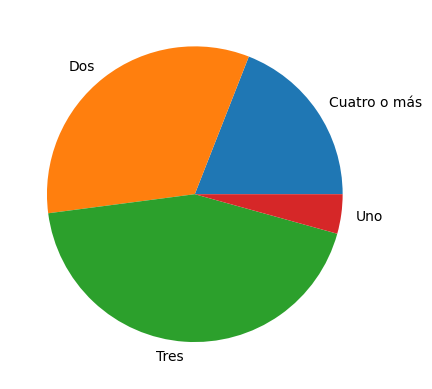

In [7]:
_cuartos_count= cuartos_count.groupby(["_Cuartos_Hogar"])["PUNT_GLOBAL"].sum().reset_index()
plt.pie(x= _cuartos_count["PUNT_GLOBAL"], labels= _cuartos_count["_Cuartos_Hogar"])
plt.show()

### Para las columnas "FAMI_EDUCACIONPADRE" y "FAMI_EDUCACIONMADRE", también agrupo algunas categorías para que la muestra esté mejor distribuida

In [8]:
education_parents= sorted(data_sample["FAMI_EDUCACIONPADRE"].unique().tolist())
education_parents

['Educación profesional completa',
 'Educación profesional incompleta',
 'Ninguno',
 'No Aplica',
 'No sabe',
 'Postgrado',
 'Primaria completa',
 'Primaria incompleta',
 'Secundaria (Bachillerato) completa',
 'Secundaria (Bachillerato) incompleta',
 'Técnica o tecnológica completa',
 'Técnica o tecnológica incompleta']

In [9]:
def unificar_categorias_educacion(df, columna):
    educacion_df= df.groupby(columna)["PUNT_GLOBAL"].count().reset_index()
    option= [
        educacion_df[columna]== "Educación profesional completa",
        educacion_df[columna]== "Técnica o tecnológica completa",
        (educacion_df[columna]== "Educación profesional incompleta") |
        (educacion_df[columna]== "Técnica o tecnológica incompleta") |
        (educacion_df[columna]== "Secundaria (Bachillerato) completa"),
        (educacion_df[columna]== "Secundaria (Bachillerato) incompleta") |
        (educacion_df[columna]== "Primaria completa"),
        (educacion_df[columna]== "Primaria incompleta") |
        (educacion_df[columna]== "Ninguno"),
        (educacion_df[columna]== "No sabe") |
        (educacion_df[columna]== "No Aplica")
    ]
    select= [
        "Profesional",
        "Técnico o Tecnológico",
        "Bachiller",
        "Primaria",
        "Ninguno",
        "No Sabe"
    ]
    educacion_df[f"_educacion_{columna[-5: ]}"]= np.select(option, select, educacion_df[columna])
    return educacion_df[[columna, f"_educacion_{columna[-5: ]}"]].drop_duplicates()


In [10]:
edu_madre= unificar_categorias_educacion(data_sample, "FAMI_EDUCACIONMADRE")
edu_padre= unificar_categorias_educacion(data_sample, "FAMI_EDUCACIONPADRE")

### Para la columna "FAMI_ESTRATOVIVIENDA" agrupo para los estratos iguales o mayores al 4 en una sola categoría

In [11]:
data_sample.groupby(["FAMI_ESTRATOVIVIENDA"])["PUNT_GLOBAL"].count().reset_index()

,FAMI_ESTRATOVIVIENDA,PUNT_GLOBAL
0,Estrato 1,68220
1,Estrato 2,66691
2,Estrato 3,40170
3,Estrato 4,15250
4,Estrato 5,3354
5,Estrato 6,2109
6,Sin Estrato,2066


In [12]:
def estrato_fam(df):
    est_df= df.copy()
    est_df["Fami_Estrato"]= np.where(
        est_df["FAMI_ESTRATOVIVIENDA"]== "Sin Estrato",
        "Estrato 1",
        np.where(
            (est_df["FAMI_ESTRATOVIVIENDA"]== "Estrato 4") | 
            (est_df["FAMI_ESTRATOVIVIENDA"]== "Estrato 5") |
            (est_df["FAMI_ESTRATOVIVIENDA"]== "Estrato 6"),
            "Estrato >= 4",
            est_df["FAMI_ESTRATOVIVIENDA"]
        )
    )
    return est_df[["FAMI_ESTRATOVIVIENDA", "Fami_Estrato"]].drop_duplicates()

In [13]:
est_v= estrato_fam(data_sample)
est_v

,FAMI_ESTRATOVIVIENDA,Fami_Estrato
0,Estrato 3,Estrato 3
2,Estrato 1,Estrato 1
5,Estrato 2,Estrato 2
9,Estrato 4,Estrato >= 4
69,Estrato 5,Estrato >= 4
108,Sin Estrato,Estrato 1
111,Estrato 6,Estrato >= 4


### Hago la misma tarea de agrupar categorías con poca representación en los datos, ahora para la columna "FAMI_PERSONASHOGAR"

In [14]:
data_sample["FAMI_PERSONASHOGAR"].unique()

array(['3 a 4', '5 a 6', 'Siete', 'Cinco', 'Cuatro', 'Dos', 'Seis',
       '7 a 8', 'Tres', '9 o más', 'Una', 'Once', 'Ocho', 'Doce o más',
       'Diez', '1 a 2', 'Nueve'], dtype=object)

In [15]:
data_sample.groupby(["FAMI_PERSONASHOGAR"])["PUNT_GLOBAL"].count().reset_index().sort_values(by= ["PUNT_GLOBAL"])

,FAMI_PERSONASHOGAR,PUNT_GLOBAL
12,Once,215
8,Doce o más,388
16,Una,437
7,Diez,574
10,Nueve,783
11,Ocho,1971
4,9 o más,2468
9,Dos,3590
14,Siete,3889
3,7 a 8,8081


In [16]:
def unificar_per_hogar(df):
    df_count= df.groupby(["FAMI_PERSONASHOGAR"])["PUNT_GLOBAL"].count().reset_index()
    select= [
        (df_count["FAMI_PERSONASHOGAR"]== "Una") | (df_count["FAMI_PERSONASHOGAR"]== "Dos") | (df_count["FAMI_PERSONASHOGAR"]== "1 a 2"),
        (df_count["FAMI_PERSONASHOGAR"]== "Tres") | (df_count["FAMI_PERSONASHOGAR"]== "Cuatro") | (df_count["FAMI_PERSONASHOGAR"]== "3 a 4"),
        (df_count["FAMI_PERSONASHOGAR"]== "Cinco") | (df_count["FAMI_PERSONASHOGAR"]== "Seis") | (df_count["FAMI_PERSONASHOGAR"]== "5 a 6"),
    ]
    option= [
        "1 a 2",
        "3 a 4",
        "5 a 6"
    ]
    df_count["_Num_Pers_Hogar"]= np.select(select, option, "> 6")
    return df_count[["FAMI_PERSONASHOGAR", "_Num_Pers_Hogar"]].drop_duplicates()

In [17]:
fam_hog= unificar_per_hogar(data_sample)

In [18]:
fam_hog

,FAMI_PERSONASHOGAR,_Num_Pers_Hogar
0,1 a 2,1 a 2
1,3 a 4,3 a 4
2,5 a 6,5 a 6
3,7 a 8,> 6
4,9 o más,> 6
5,Cinco,5 a 6
6,Cuatro,3 a 4
7,Diez,> 6
8,Doce o más,> 6
9,Dos,1 a 2


### Ahora reemplazo las nuevas categorías por columnas en la muestra de datos

In [19]:
data_samp_cuart= pd.merge(data_sample, cuart, how= "left", on= ["FAMI_CUARTOSHOGAR"])
data_samp_fmmadre= pd.merge(data_samp_cuart, edu_madre, how= "left", on= ["FAMI_EDUCACIONMADRE"])
data_samp_fmpadre= pd.merge(data_samp_fmmadre, edu_padre, how= "left", on= ["FAMI_EDUCACIONPADRE"])
data_samp_est= pd.merge(data_samp_fmpadre, est_v, how= "left", on= ["FAMI_ESTRATOVIVIENDA"])
clean_data_samp= pd.merge(data_samp_est, fam_hog, how= "left", on= ["FAMI_PERSONASHOGAR"])
clean_data_samp.drop(columns= ["FAMI_CUARTOSHOGAR", "FAMI_EDUCACIONMADRE", "FAMI_EDUCACIONPADRE", "FAMI_ESTRATOVIVIENDA", "FAMI_PERSONASHOGAR"], inplace= True)

### Calcular las estadísticas descriptivas generales del puntaje global 

In [20]:
mean_gp= clean_data_samp["PUNT_GLOBAL"].mean()
std_gp= clean_data_samp["PUNT_GLOBAL"].std()
cv_gp= std_gp/ mean_gp
print(f"Promedio general del puntaje global: {mean_gp: .2f}")
print(f"Desviación estándar general del puntaje global: {std_gp: .2f}")
print(f"Coeficiente de variación general del puntaje global: {cv_gp: .2f}")

Promedio general del puntaje global:  266.05
Desviación estándar general del puntaje global:  51.38
Coeficiente de variación general del puntaje global:  0.19


### Calcular estadísticas descriptivas de acuerdo con el estrato de la vivienda del estudiante

In [21]:
gp_est= clean_data_samp.groupby(["Fami_Estrato"]).agg(promedio= ("PUNT_GLOBAL", "mean"), desvest= ("PUNT_GLOBAL", "std")).reset_index()
gp_est["promedio"]= np.round(gp_est["promedio"], decimals= 2)
gp_est["desvest"]= np.round(gp_est["desvest"], decimals= 2)
gp_est["cv"]= gp_est["desvest"]/ gp_est["promedio"]
gp_est["cv"]= np.round(gp_est["cv"], decimals= 2)
gp_est

,Fami_Estrato,promedio,desvest,cv
0,Estrato 1,249.52,45.03,0.18
1,Estrato 2,263.88,46.91,0.18
2,Estrato 3,278.34,51.02,0.18
3,Estrato >= 4,305.33,58.52,0.19


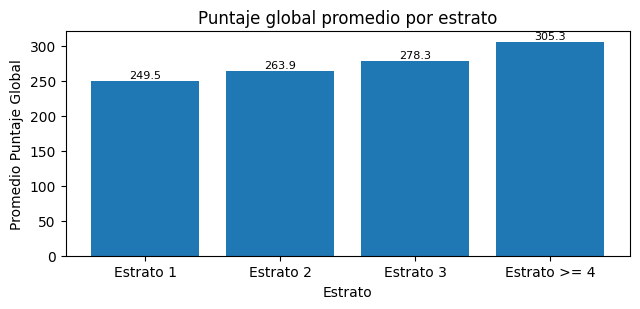

In [22]:
fig1, ax1 = plt.subplots(figsize=(6.5, 3.2))

ax1.bar(gp_est["Fami_Estrato"], gp_est["promedio"])
ax1.set_title("Puntaje global promedio por estrato")
ax1.set_ylabel("Promedio Puntaje Global")
ax1.set_xlabel("Estrato")

# Etiquetas sobre las barras
for i, v in enumerate(gp_est["promedio"]):
    ax1.text(i, v + 1.5, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Para evaluar las condiciones familiares, primero voy a evaluar las condiciones de estudio creando una variable combinando los campos "_Cuartos_Hogar" y "_Num_Pers_Hogar" y evaluar las estadísticas del puntaje global

In [23]:
clean_data_samp["cond_est"]= clean_data_samp["_Cuartos_Hogar"].astype(str)+ "_"+ clean_data_samp["_Num_Pers_Hogar"].astype(str)

In [24]:
gp_cond_est= clean_data_samp.groupby(["cond_est"]).agg(promedio= ("PUNT_GLOBAL", "mean"), desvest= ("PUNT_GLOBAL", "std")).reset_index().sort_values(by= ["promedio"])
gp_cond_est["promedio"]= np.round(gp_cond_est["promedio"], decimals= 2)
gp_cond_est["desvest"]= np.round(gp_cond_est["desvest"], decimals= 2)
gp_cond_est["cv"]= gp_cond_est["desvest"]/ gp_cond_est["promedio"]
gp_cond_est["cv"]= np.round(gp_cond_est["cv"], decimals= 2)
gp_cond_est

,cond_est,promedio,desvest,cv
15,Uno_> 6,234.66,47.11,0.20
7,Dos_> 6,239.27,45.31,0.19
0,Cuatro o más_1 a 2,242.62,57.80,0.24
14,Uno_5 a 6,242.78,46.28,0.19
11,Tres_> 6,249.45,46.08,0.18
13,Uno_3 a 4,252.41,48.74,0.19
12,Uno_1 a 2,253.37,51.34,0.20
6,Dos_5 a 6,253.41,45.54,0.18
8,Tres_1 a 2,257.10,54.93,0.21
3,Cuatro o más_> 6,257.93,48.54,0.19


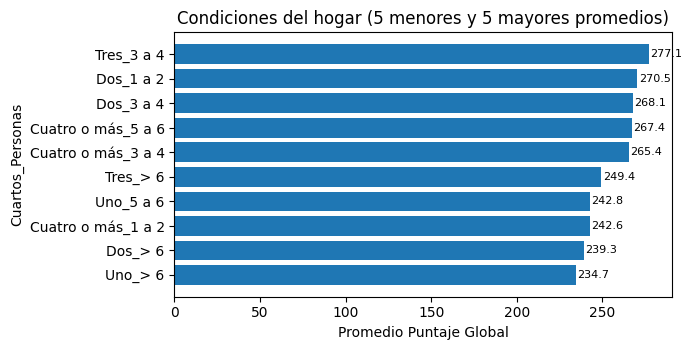

In [25]:
top_bottom = pd.concat([
    gp_cond_est.nsmallest(5, "promedio"),
    gp_cond_est.nlargest(5, "promedio")
]).copy()

# Orden para visualización horizontal
top_bottom = top_bottom.sort_values("promedio")

fig2, ax2 = plt.subplots(figsize=(7.0, 3.6))

ax2.barh(top_bottom["cond_est"], top_bottom["promedio"])
ax2.set_title("Condiciones del hogar (5 menores y 5 mayores promedios)")
ax2.set_xlabel("Promedio Puntaje Global")
ax2.set_ylabel("Cuartos_Personas")

# Etiquetas al final de cada barra
for y, v in enumerate(top_bottom["promedio"]):
    ax2.text(v + 0.8, y, f"{v:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Ahora podemos evaluar que tanto influye la educación de los padres en el desempeño de las pruebas

In [26]:
gp_mad= clean_data_samp.groupby(["_educacion_MADRE"]).agg(promedio= ("PUNT_GLOBAL", "mean"), desvest= ("PUNT_GLOBAL", "std")).reset_index().sort_values(by= ["promedio"])
gp_mad["promedio"]= np.round(gp_mad["promedio"], decimals= 2)
gp_mad["desvest"]= np.round(gp_mad["desvest"], decimals= 2)
gp_mad["cv"]= gp_mad["desvest"]/ gp_mad["promedio"]
gp_mad["cv"]= np.round(gp_mad["cv"], decimals= 2)
gp_mad

,_educacion_MADRE,promedio,desvest,cv
1,Ninguno,240.98,42.90,0.18
4,Primaria,252.24,44.52,0.18
2,No Sabe,267.22,55.33,0.21
0,Bachiller,269.74,47.81,0.18
6,Técnico o Tecnológico,286.76,47.48,0.17
5,Profesional,303.07,52.39,0.17
3,Postgrado,328.06,53.92,0.16


In [27]:
gp_pad= clean_data_samp.groupby(["_educacion_PADRE"]).agg(promedio= ("PUNT_GLOBAL", "mean"), desvest= ("PUNT_GLOBAL", "std")).reset_index().sort_values(by= ["promedio"])
gp_pad["promedio"]= np.round(gp_pad["promedio"], decimals= 2)
gp_pad["desvest"]= np.round(gp_pad["desvest"], decimals= 2)
gp_pad["cv"]= gp_pad["desvest"]/ gp_pad["promedio"]
gp_pad["cv"]= np.round(gp_pad["cv"], decimals= 2)
gp_pad

,_educacion_PADRE,promedio,desvest,cv
1,Ninguno,245.31,44.10,0.18
4,Primaria,255.91,45.84,0.18
2,No Sabe,269.29,51.14,0.19
0,Bachiller,271.57,48.18,0.18
6,Técnico o Tecnológico,289.14,47.97,0.17
5,Profesional,304.24,52.71,0.17
3,Postgrado,336.80,50.76,0.15


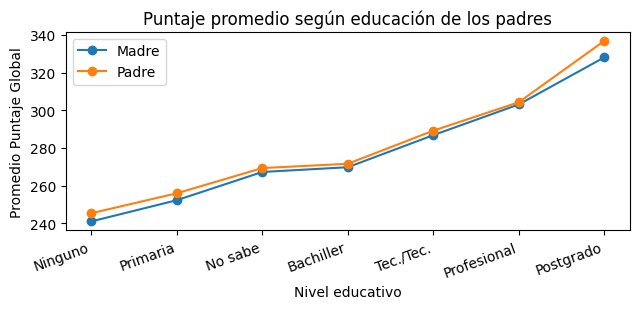

In [28]:
fig3, ax3 = plt.subplots(figsize=(6.5, 3.2))

x = np.arange(len(gp_mad))

ax3.plot(x, gp_mad["promedio"], marker="o", label="Madre")
ax3.plot(x, gp_pad["promedio"], marker="o", label="Padre")

ax3.set_xticks(x)
ax3.set_xticklabels(
    ["Ninguno","Primaria","No sabe","Bachiller","Tec./Tec.","Profesional","Postgrado"],
    rotation=20, ha="right"
)
ax3.set_title("Puntaje promedio según educación de los padres")
ax3.set_ylabel("Promedio Puntaje Global")
ax3.set_xlabel("Nivel educativo")
ax3.legend()

plt.tight_layout()
plt.show()

### Ahora la combinación de educación de sus padres, para confirmar si eleva el puntaje del estudiante

In [29]:
clean_data_samp["comb_padres"]= clean_data_samp["_educacion_MADRE"].astype(str)+ "_"+ clean_data_samp["_educacion_PADRE"]

In [30]:
gp_padres= clean_data_samp.groupby(["comb_padres"]).agg(promedio= ("PUNT_GLOBAL", "mean"), desvest= ("PUNT_GLOBAL", "std")).reset_index().sort_values(by= ["promedio"])
gp_padres["promedio"]= np.round(gp_padres["promedio"], decimals= 2)
gp_padres["desvest"]= np.round(gp_padres["desvest"], decimals= 2)
gp_padres["cv"]= gp_padres["desvest"]/ gp_padres["promedio"]
gp_padres["cv"]= np.round(gp_padres["cv"], decimals= 2)
gp_padres

,comb_padres,promedio,desvest,cv
10,Ninguno_Postgrado,235.73,49.17,0.21
8,Ninguno_Ninguno,236.59,41.49,0.18
15,No Sabe_Ninguno,242.13,51.40,0.21
9,Ninguno_No Sabe,246.53,45.60,0.18
11,Ninguno_Primaria,247.93,43.79,0.18
32,Primaria_Primaria,248.89,43.85,0.18
29,Primaria_Ninguno,249.15,43.42,0.17
18,No Sabe_Primaria,254.28,45.68,0.18
7,Ninguno_Bachiller,254.85,43.38,0.17
1,Bachiller_Ninguno,257.65,44.84,0.17


In [31]:
clean_data_samp.to_csv("data_sample.csv", index= False)

In [32]:
clean_data_samp

,PUNT_GLOBAL,_Cuartos_Hogar,_educacion_MADRE,_educacion_PADRE,Fami_Estrato,_Num_Pers_Hogar,cond_est,comb_padres
0,295.0,Tres,Bachiller,Bachiller,Estrato 3,3 a 4,Tres_3 a 4,Bachiller_Bachiller
1,295.0,Tres,Bachiller,Bachiller,Estrato 3,3 a 4,Tres_3 a 4,Bachiller_Bachiller
2,307.0,Cuatro o más,Primaria,Ninguno,Estrato 1,5 a 6,Cuatro o más_5 a 6,Primaria_Ninguno
3,232.0,Dos,Primaria,Bachiller,Estrato 2,3 a 4,Dos_3 a 4,Primaria_Bachiller
4,242.0,Cuatro o más,Primaria,Primaria,Estrato 1,> 6,Cuatro o más_> 6,Primaria_Primaria
...,...,...,...,...,...,...,...,...
197855,243.0,Cuatro o más,Primaria,Primaria,Estrato >= 4,5 a 6,Cuatro o más_5 a 6,Primaria_Primaria
197856,269.0,Dos,Ninguno,Bachiller,Estrato 1,3 a 4,Dos_3 a 4,Ninguno_Bachiller
197857,175.0,Dos,Bachiller,Primaria,Estrato 2,1 a 2,Dos_1 a 2,Bachiller_Primaria
197858,263.0,Dos,Técnico o Tecnológico,Primaria,Estrato 2,3 a 4,Dos_3 a 4,Técnico o Tecnológico_Primaria
